In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.io import savemat

from importlib import reload
import kan
reload(kan)

from kan import KAN

In [2]:
x_min_test = 0
x_max_test = 1

In [3]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

#selected_indices = kan.select_equidistant_basis_indices(
#    total_basis=b_coef.shape[0],
#    num_selected=12,
#)
selected_indices = [8, 10, 12, 14, 16, 18, 20, 22]#np.arange(8,10)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

mat_folder = "new_consistent_affine_2-4-1_exports"
os.makedirs(mat_folder, exist_ok=True)

Selected indices: [8, 10, 12, 14, 16, 18, 20, 22]
Selected detunings: tensor([-1.3000e+11, -1.5000e+11, -1.7000e+11, -1.9000e+11, -2.1000e+11,
        -2.3000e+11, -2.5000e+11, -2.7000e+11])
Selected b_coef shape: torch.Size([8, 8])


In [4]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_train = 1000
n_test = 300

x_max_test = 1
x_min_test = 0
#input_abs_max = 3.0 #max(abs(x_min_test), abs(x_max_test))
#input_abs_max = [1.0, 3.0]

x_train = x_min_test + (x_max_test - x_min_test) * torch.rand(n_train, 2)
x_test = x_min_test + (x_max_test - x_min_test) * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y = 0.3 * x1**2 + torch.cos(3.0 * x2)

    return y

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [5]:
model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[4],
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    layer_type="photonic_interval_affine_clean",
    b_coef_selected=b_coef_selected,
    input_neg_max = [0.2, 3.0],
    input_pos_max = [1.0, 3.0],
    basis_min=0.05,
    basis_max=2.0,
    dropout_prob=0.0,
    debug=False,
)

model = model.to(device=device, dtype=torch.float64)

In [6]:
x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)
x_test = x_test.to(device=device, dtype=torch.float64)
y_test = y_test.to(device=device, dtype=torch.float64)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 5000

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"train loss = {loss.item():.8f} | "
            f"test loss = {test_loss.item():.8f}"
        )

Epoch     0 | train loss = 0.47296004 | test loss = 0.45838352
Epoch   500 | train loss = 0.00035238 | test loss = 0.00035608
Epoch  1000 | train loss = 0.00011719 | test loss = 0.00011362
Epoch  1500 | train loss = 0.00007980 | test loss = 0.00007840
Epoch  2000 | train loss = 0.00005588 | test loss = 0.00005580
Epoch  2500 | train loss = 0.00003791 | test loss = 0.00003821
Epoch  3000 | train loss = 0.00002573 | test loss = 0.00002577
Epoch  3500 | train loss = 0.00001847 | test loss = 0.00001806
Epoch  4000 | train loss = 0.00001490 | test loss = 0.00001411
Epoch  4500 | train loss = 0.00001339 | test loss = 0.00001238


## Final train/test MSE

In [7]:
model.eval()

with torch.no_grad():
    y_pred_train = model(x_train)
    y_pred_test = model(x_test)

    train_mse = nn.functional.mse_loss(y_pred_train, y_train)
    test_mse = nn.functional.mse_loss(y_pred_test, y_test)

print(f"Final train MSE: {train_mse.item():.10f}")
print(f"Final test MSE:  {test_mse.item():.10f}")

Final train MSE: 0.0000132090
Final test MSE:  0.0000119625


In [8]:
model.print_photonic_affine_params()

Photonic interval affine parameters:

Layer 0: PhotonicBasisActivationLayerIntervalAffineClean
  in_count = 2
  out_count = 4
  input_neg_max = 0.2
  input_pos_max = 1.0
  basis interval = [0.05, 2.0]
  alpha shape = (2,)
  beta shape  = (2,)
  alpha values = [1.625 1.625]
  beta values  = [0.375 0.375]
  alpha unique = [1.625]
  beta unique  = [0.375]

Layer 1: PhotonicBasisActivationLayerIntervalAffineClean
  in_count = 4
  out_count = 1
  input_neg_max = 3.0
  input_pos_max = 3.0
  basis interval = [0.05, 2.0]
  alpha shape = (4,)
  beta shape  = (4,)
  alpha values = [0.32499999 0.32499999 0.32499999 0.32499999]
  beta values  = [1.02499998 1.02499998 1.02499998 1.02499998]
  alpha unique = [0.32499999]
  beta unique  = [1.02499998]


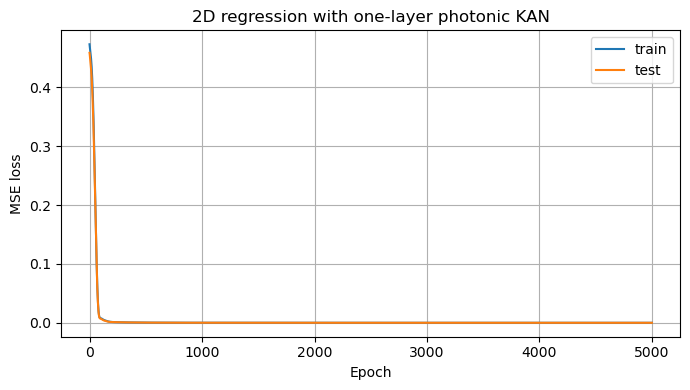

In [9]:
savemat(
    os.path.join(mat_folder, "loss_curves.mat"),
    {
        "plot_type": "loss_curves",
        "epoch": np.arange(num_epochs),
        "train_losses": np.array(train_losses),
        "test_losses": np.array(test_losses),
        "num_epochs": num_epochs,
    },
)

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer photonic KAN")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

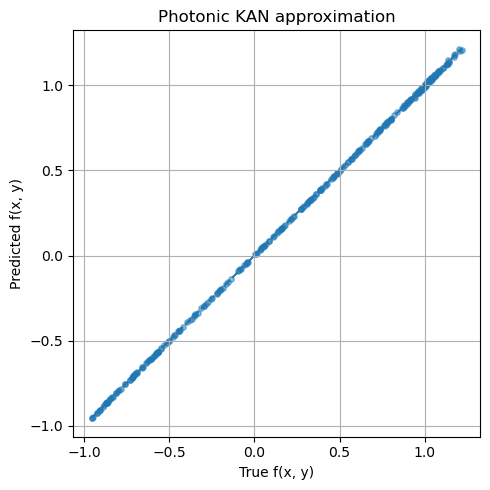

In [10]:
model.eval()

with torch.no_grad():
    y_pred_test = model(x_test)

savemat(
    os.path.join(mat_folder, "true_vs_pred_test.mat"),
    {
        "plot_type": "true_vs_pred_test",
        "x_test": x_test.detach().cpu().numpy(),
        "y_test": y_test.detach().cpu().numpy(),
        "y_pred_test": y_pred_test.detach().cpu().numpy(),
    },
)

plt.figure(figsize=(5, 5))
plt.scatter(
    y_test.detach().cpu().numpy(),
    y_pred_test.detach().cpu().numpy(),
    alpha=0.5,
    s=15,
)

minv = min(y_test.min().item(), y_pred_test.min().item())
maxv = max(y_test.max().item(), y_pred_test.max().item())

plt.plot([minv, maxv], [minv, maxv], linestyle="--")
plt.xlabel("True f(x, y)")
plt.ylabel("Predicted f(x, y)")
plt.title("Photonic KAN approximation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
model.eval()

with torch.no_grad():
    y_pred, activations = model(x_train, return_all=True)

z = activations[1]

z_min = z.min().item()
z_max = z.max().item()

print("hidden min:", z.min().item())
print("hidden max:", z.max().item())

hidden min: -1.4104922225119385
hidden max: 3.0037991321310527


Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/basis_functions_L0_in0.mat


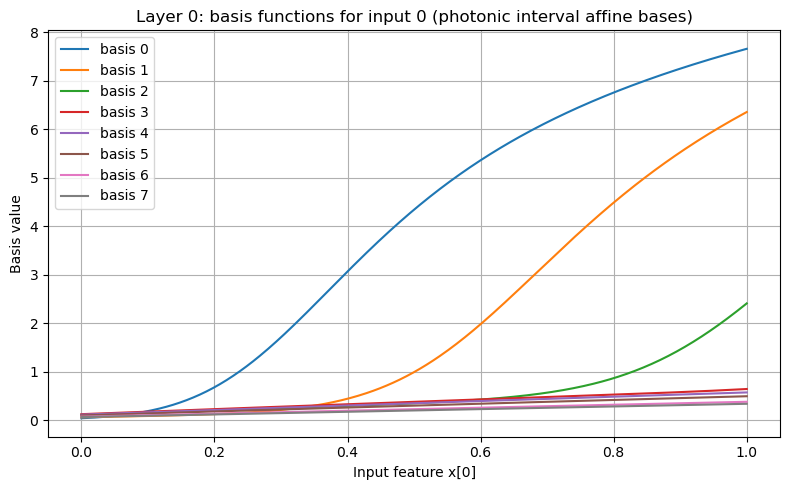

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/basis_functions_L0_in1.mat


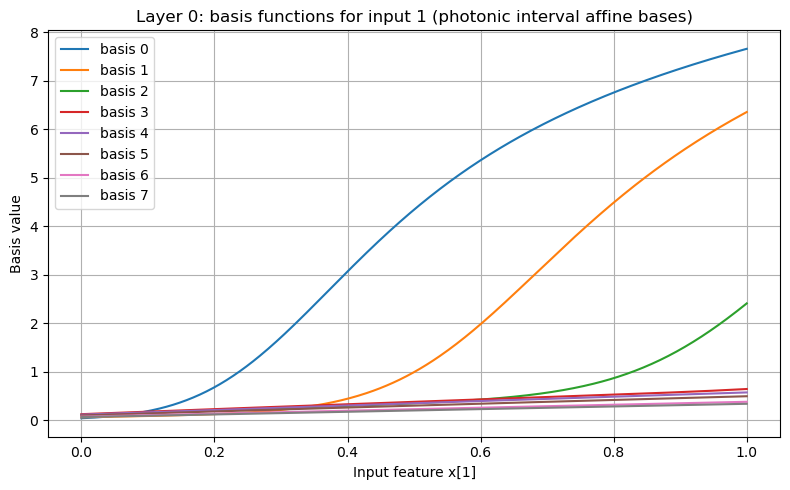

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/basis_functions_L1_in0.mat


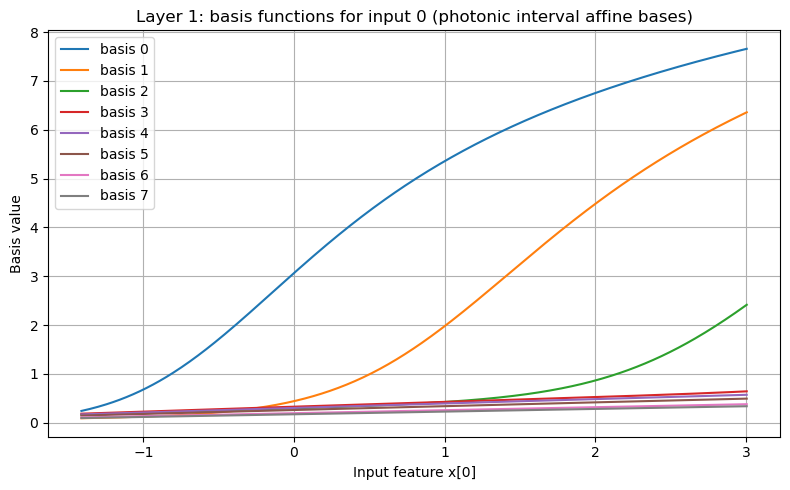

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out0_in0.mat


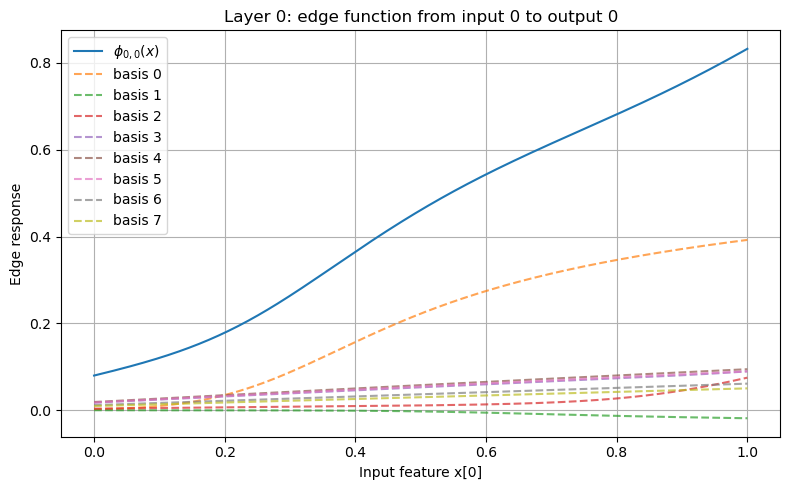

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out0_in1.mat


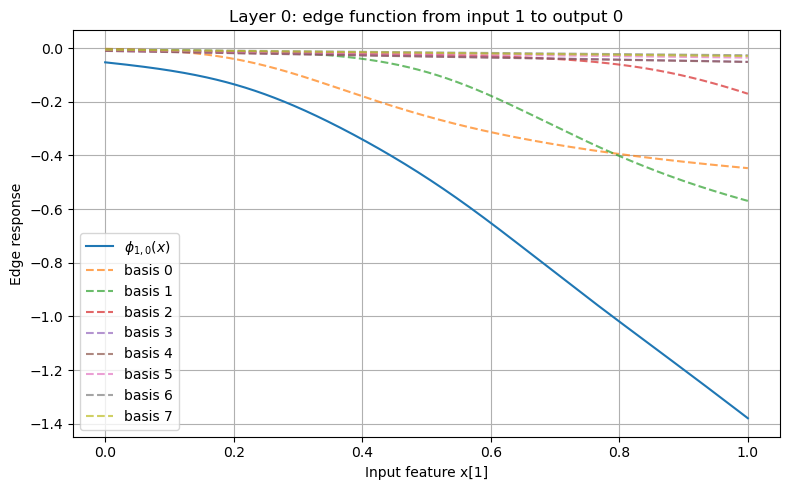

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out1_in0.mat


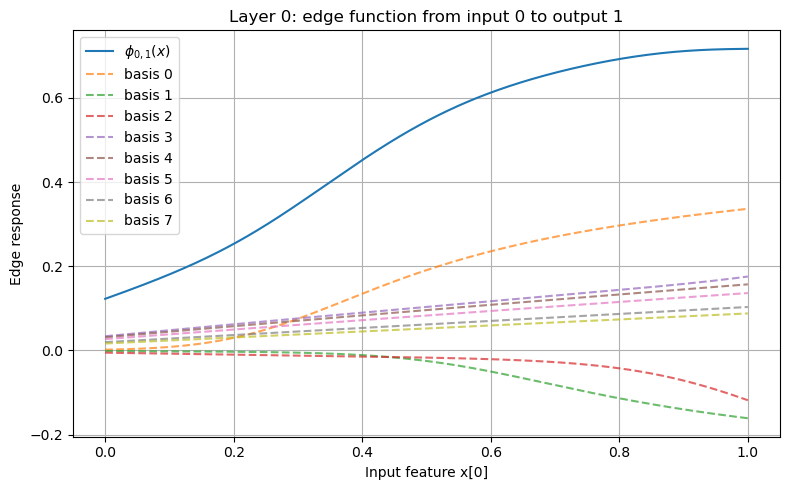

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out1_in1.mat


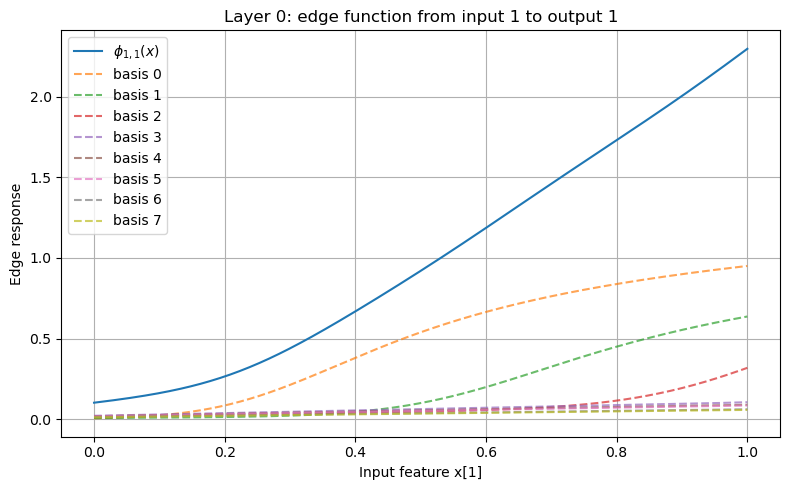

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out2_in0.mat


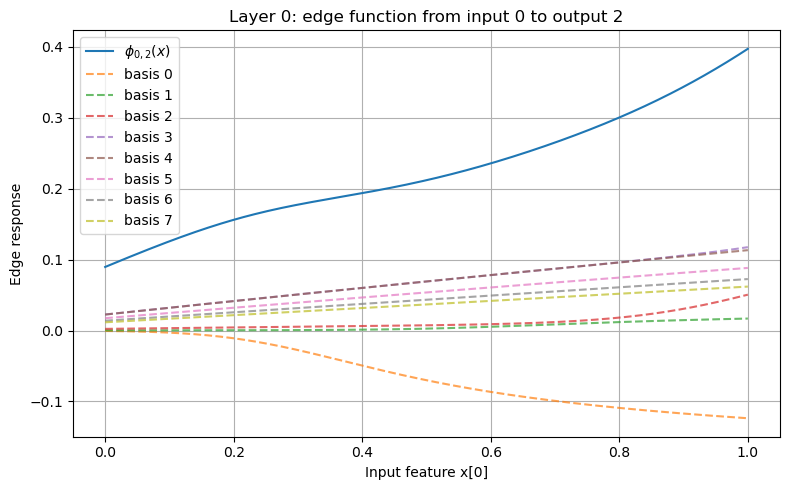

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out2_in1.mat


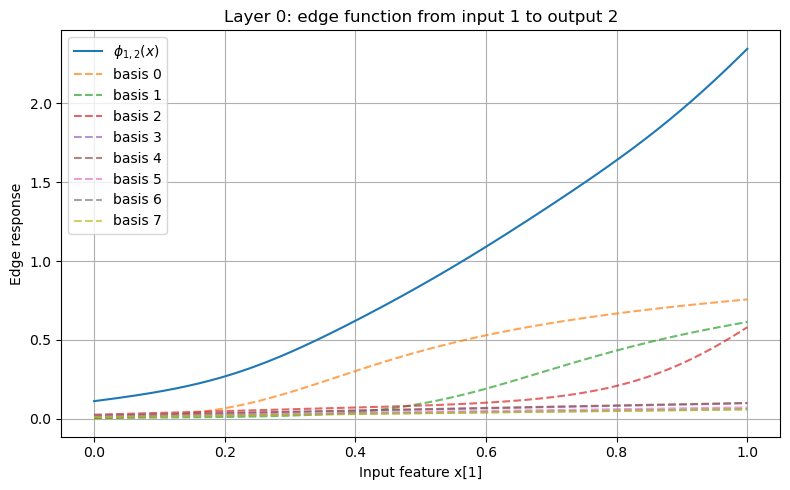

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out3_in0.mat


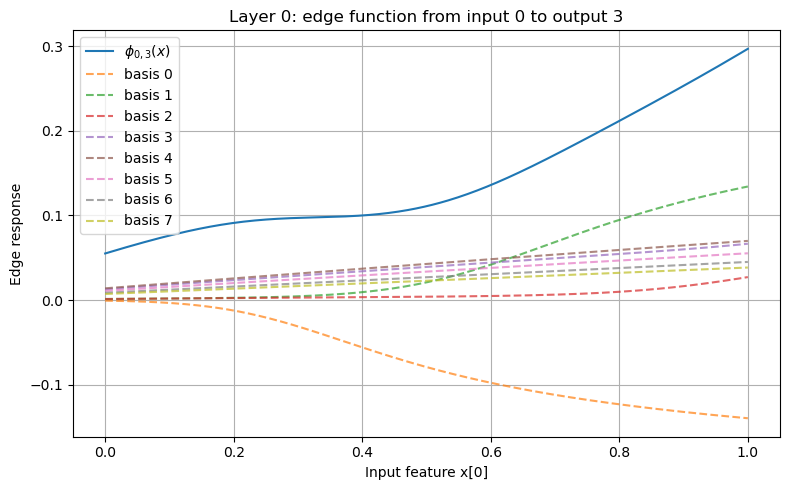

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L0_out3_in1.mat


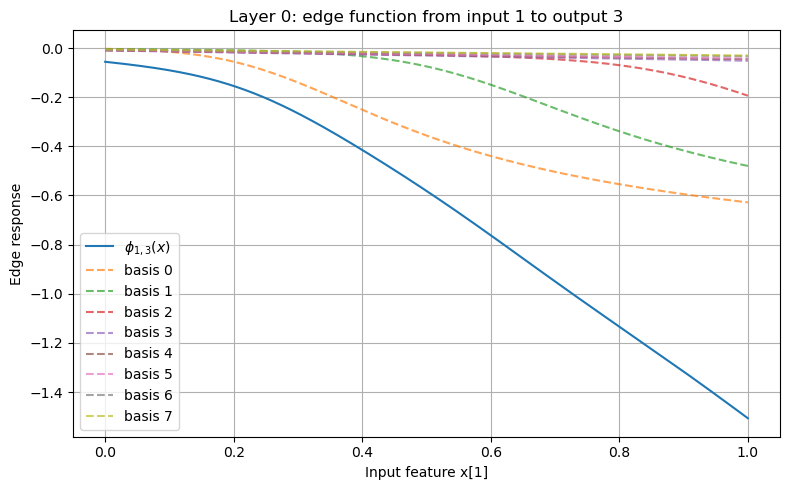

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L1_out0_in0.mat


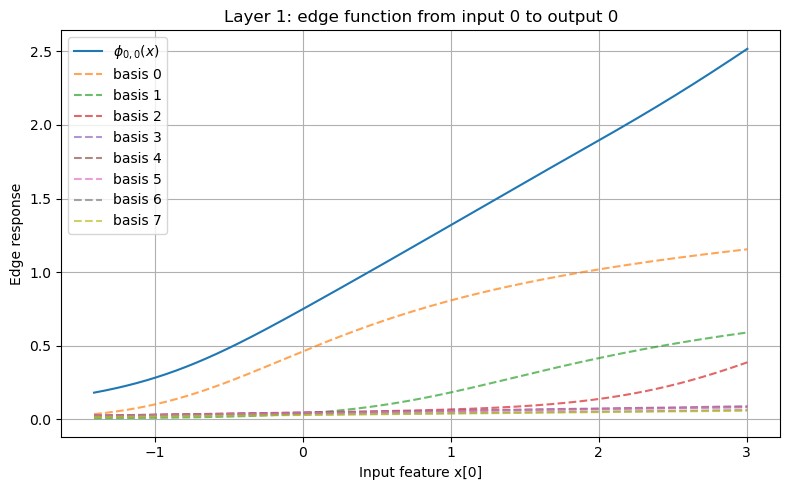

basis shape: torch.Size([400, 8])
basis finite: True
phi finite: True
Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/edge_function_L1_out0_in1.mat


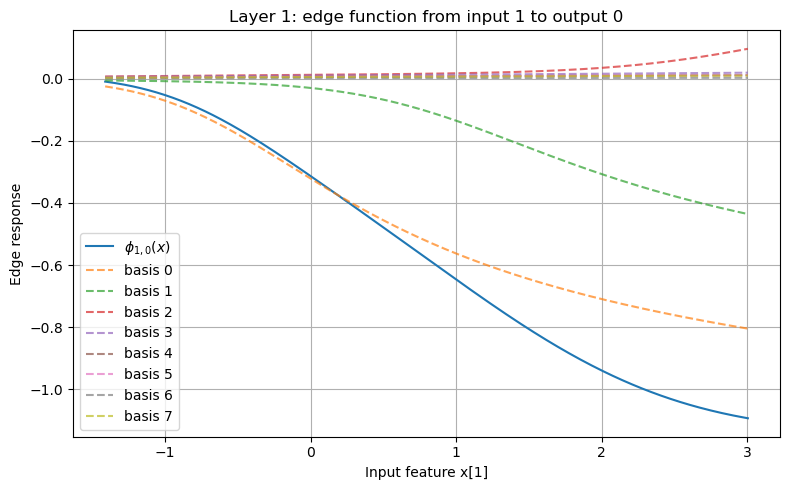

In [16]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), mat_export_path="basis_functions_L0_in0.mat", mat_export_dir=mat_folder)
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), mat_export_path="basis_functions_L0_in1.mat", mat_export_dir=mat_folder)
model.plot_basis_functions(layer_idx=1, in_idx=0, x_range=(z_min, z_max), mat_export_path="basis_functions_L1_in0.mat", mat_export_dir=mat_folder)

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out1_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out1_in1.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=2, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out2_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=2, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out2_in1.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=3, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out3_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=3, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_function_L0_out3_in1.mat", mat_export_dir=mat_folder)

model.plot_edge_function(layer_idx=1, out_idx=0, in_idx=0, x_range=(z_min, z_max), show_basis=True, mat_export_path="edge_function_L1_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=1, out_idx=0, in_idx=1, x_range=(z_min, z_max), show_basis=True, mat_export_path="edge_function_L1_out0_in1.mat", mat_export_dir=mat_folder)

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out0_in0.mat


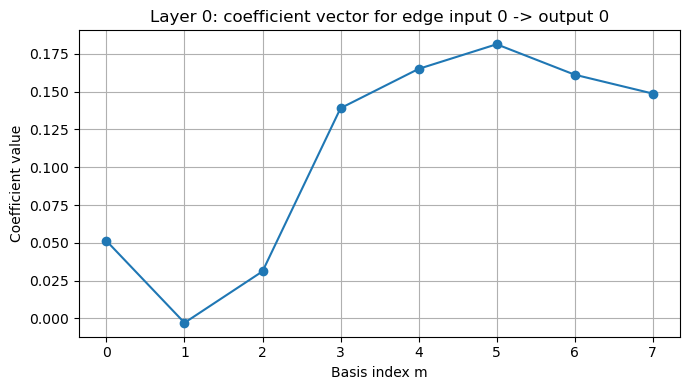

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out0_in1.mat


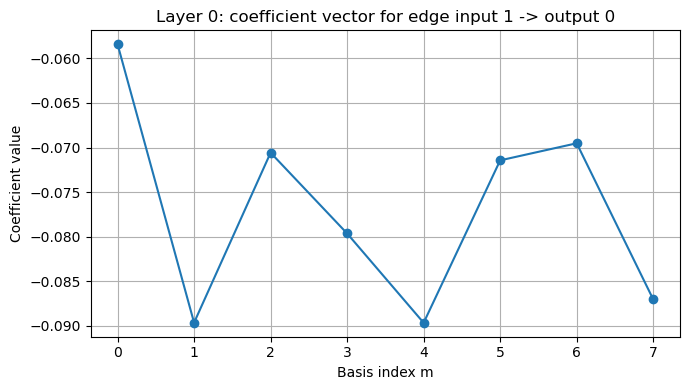

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out1_in0.mat


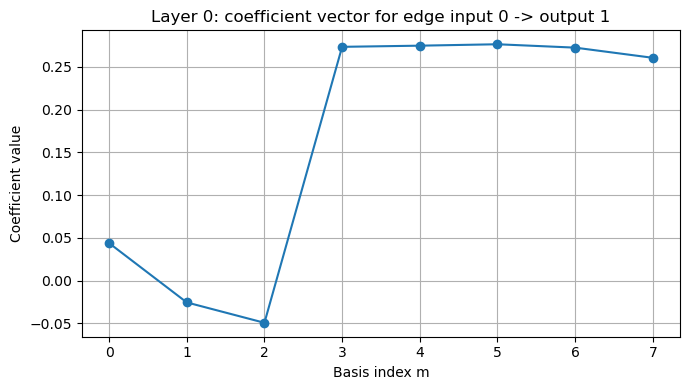

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out1_in1.mat


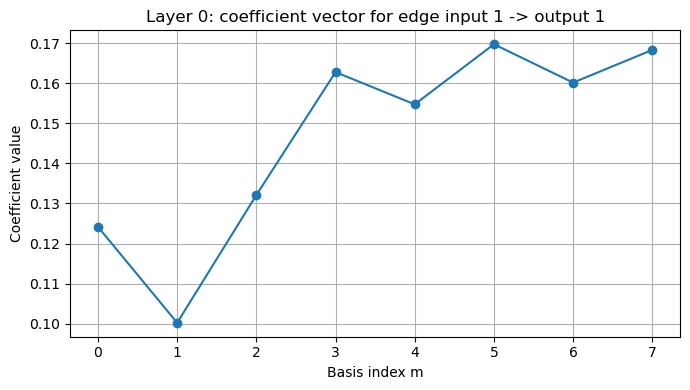

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out2_in0.mat


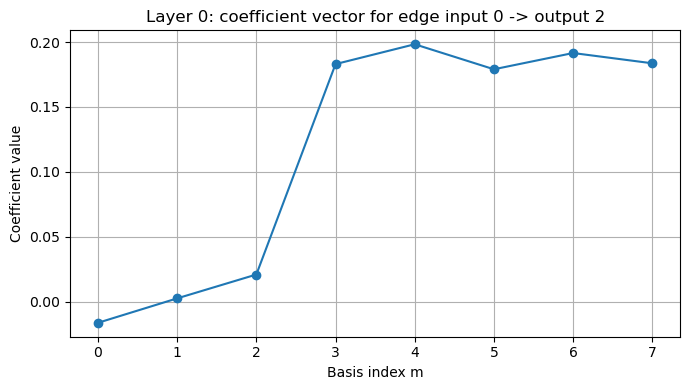

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out2_in1.mat


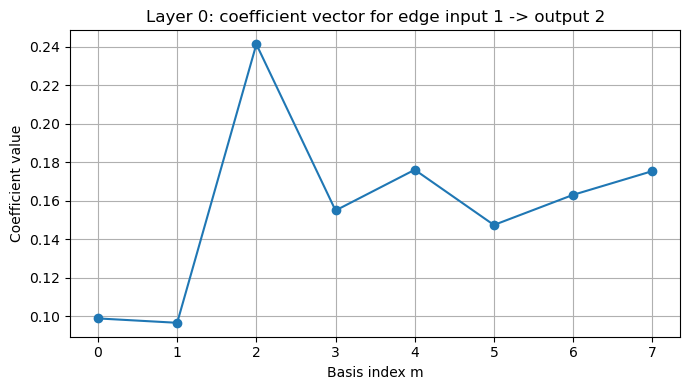

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out3_in0.mat


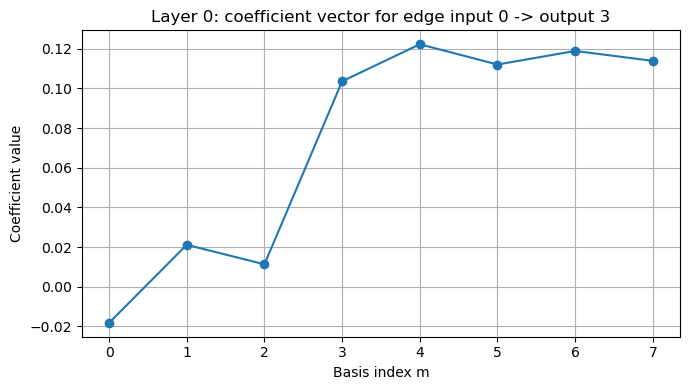

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L0_out3_in1.mat


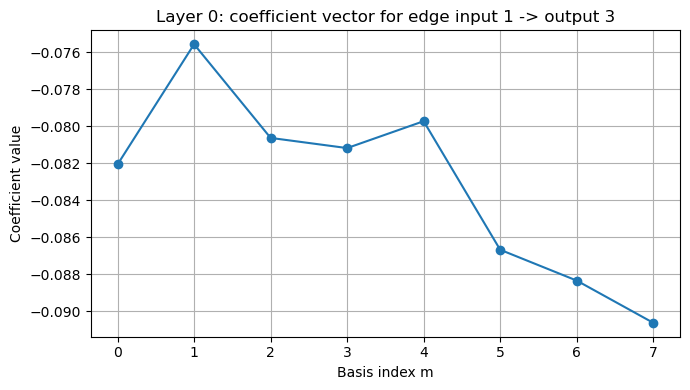

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L1_out0_in0.mat


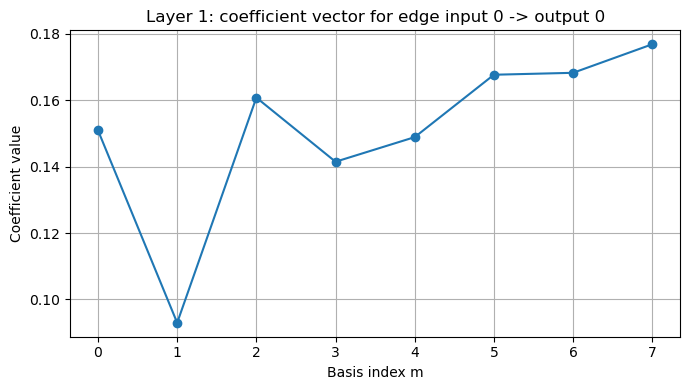

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/coefficient_vector_L1_out0_in1.mat


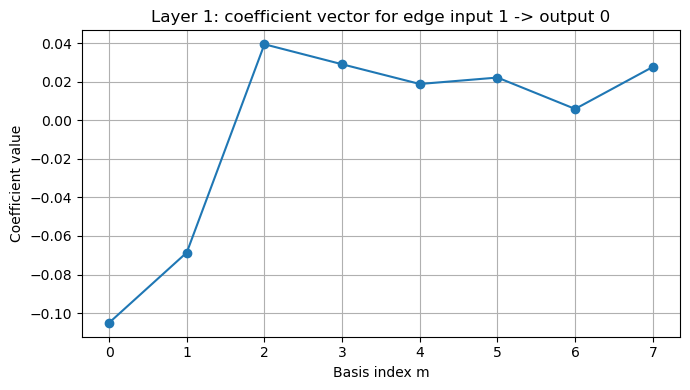

In [17]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0, mat_export_path="coefficient_vector_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1, mat_export_path="coefficient_vector_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0, mat_export_path="coefficient_vector_L0_out1_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1, mat_export_path="coefficient_vector_L0_out1_in1.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=2, in_idx=0, mat_export_path="coefficient_vector_L0_out2_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=2, in_idx=1, mat_export_path="coefficient_vector_L0_out2_in1.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=3, in_idx=0, mat_export_path="coefficient_vector_L0_out3_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=3, in_idx=1, mat_export_path="coefficient_vector_L0_out3_in1.mat", mat_export_dir=mat_folder)

model.plot_coefficient_vector(layer_idx=1, out_idx=0, in_idx=0, mat_export_path="coefficient_vector_L1_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=1, out_idx=0, in_idx=1, mat_export_path="coefficient_vector_L1_out0_in1.mat", mat_export_dir=mat_folder)

## x2 = 0.5

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/target_approximation_0.5_varied_x0.mat


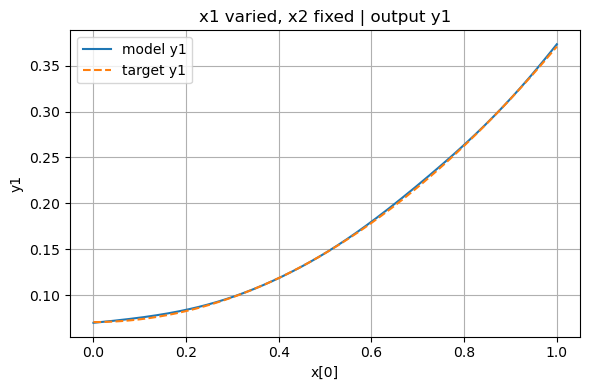

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/target_approximation_0.5_varied_x1.mat


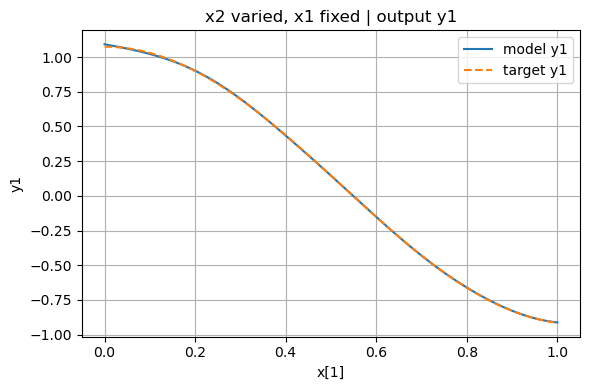

In [14]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.5, 0.5],
    resolution=400,
    mat_export_prefix="target_approximation_0.5",
    mat_export_dir=mat_folder,
)

## x2 = 0

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/target_approximation_0.0_varied_x0.mat


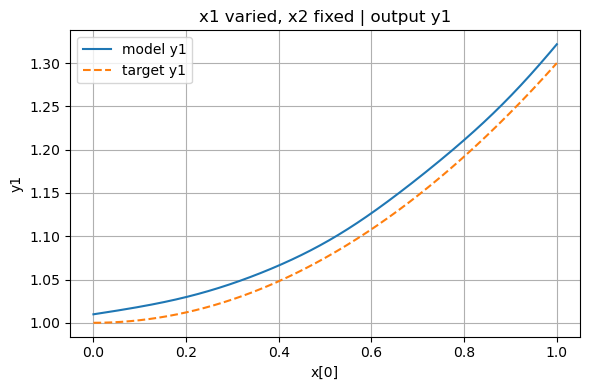

Saved MATLAB plot data to: new_consistent_affine_2-4-1_exports/target_approximation_0.0_varied_x1.mat


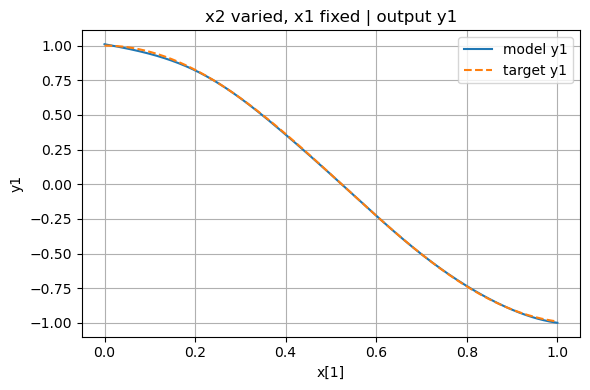

In [15]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.0, 0.0],
    resolution=400,
    mat_export_prefix="target_approximation_0.0",
    mat_export_dir=mat_folder,
)